# Analisis Korelasi Silang Resistivitas dan Porositas Efektif
### Sumur FORGE 78B-32, Utah FORGE Geothermal Site

Notebook ini menguji keterkaitan empiris antara resistivitas dan porositas efektif ($\varphi_e$) yang menjadi dasar fisis penggunaan data magnetotelurik (MT) untuk memprediksi porositas. Analisis dipisahkan menjadi dua pasangan yang menjawab pertanyaan berbeda:

1. **AT90 terhadap $\varphi_e$** yaitu korelasi petrofisika pada skala sumur, tanpa pengaruh inversi maupun resampling. Pasangan ini menjadi acuan batas atas keterkaitan yang mungkin dicapai.
2. **Resistivitas inversi MT terhadap $\varphi_e$** yaitu korelasi yang benar-benar dilihat oleh model machine learning saat pelatihan.

Empat analisis dilakukan secara berurutan: koefisien korelasi (keseluruhan dan per zona petrofisika), plot sebar log-log beserta pendugaan eksponen Archie empiris, korelasi silang berbasis lag kedalaman untuk memverifikasi keselarasan (alignment) profil, dan perbandingan kekuatan korelasi AT90 versus MT untuk mengisolasi efek resolusi.

## 1. Konfigurasi

Sesuaikan tiga path berikut dengan nama file di komputermu. Ketiga file menggunakan pemisah titik koma (`;`). `ZONE_BOUNDARY_TVDSS` adalah batas antar zona petrofisika dalam TVD_SS. Perlu diperhatikan bahwa pada file ini sumbu kedalaman memakai konvensi **positif ke atas** (nilai besar positif berarti dangkal, nilai negatif berarti dalam).

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.stats import pearsonr, spearmanr
from scipy.ndimage import gaussian_filter1d

# --- PATH FILE (sesuaikan) ---
PATH_AT90 = "78B_AT90(ohm.m).csv"        # log resistivitas AT90
PATH_MT   = "A1_Near 78B.csv"            # profil resistivitas inversi 2-D (kolom mesh terdekat sumur)
PATH_PHI  = "effective_porosity_split_78B.csv"         # log porositas efektif (target: PHIE)

# --- PARAMETER ANALISIS ---
GRID_STEP           = 1.0     # resolusi grid harmonisasi (meter)
ZONE_BOUNDARY_TVDSS = 175.0   # batas zona petrofisika (TVD_SS)
PHI_FLOOR           = 0.005   # ambang bawah porositas untuk fit log-log Archie
SIGMA_SMOOTH        = 25      # sigma Gaussian (indeks) untuk versi AT90 dihaluskan

# --- PARAMETER HEADER LAS (FORGE 78B-32) ---
FNUM      = 1.0     # a, konstanta tortuositas (Formation Factor Numerator)
FEXP      = 2.0     # m, eksponen sementasi asumsi operator (Exponent m)
RW_HEADER = 1.0     # ohm.m, resistivitas air formasi / connate water (RW)
MDEN      = 2.71    # g/cc, densitas matriks (LIME) untuk koreksi porositas
BHT_F     = 353.72  # deg F, bottom hole temperature

plt.rcParams.update({"figure.dpi":110, "font.size":10, "axes.grid":True, "grid.alpha":0.3})

## 2. Pemuatan dan Penyeragaman Data

Setiap file dimuat, kolomnya dibakukan, lalu diurutkan menurut kedalaman. Baris porositas tanpa nilai `PHIE` dibuang karena tidak dapat dipakai sebagai target.

In [13]:
at = pd.read_csv(PATH_AT90, sep=';'); at.columns = ['Z','AT90']
mt = pd.read_csv(PATH_MT,   sep=';'); mt.columns = ['Z','inv']
phi = pd.read_csv(PATH_PHI, sep=';')

at  = at.sort_values('Z').reset_index(drop=True)
mt  = mt.sort_values('Z').reset_index(drop=True)
phi = phi.sort_values('DEPTH').dropna(subset=['PHIE']).reset_index(drop=True)

print(f"AT90 : {len(at):6d} titik | resistivitas {at.AT90.min():.2f}-{at.AT90.max():.2f} ohm.m | TVD_SS {at.Z.min():.1f} s/d {at.Z.max():.1f}")
print(f"MT   : {len(mt):6d} titik | resistivitas {mt.inv.min():.2f}-{mt.inv.max():.2f} ohm.m | TVD_SS {mt.Z.min():.1f} s/d {mt.Z.max():.1f}")
print(f"PHIE : {len(phi):6d} titik | porositas   {phi.PHIE.min():.4f}-{phi.PHIE.max():.4f}     | TVD_SS {phi.DEPTH.min():.1f} s/d {phi.DEPTH.max():.1f}")

AT90 :  11187 titik | resistivitas 0.15-594.36 ohm.m | TVD_SS -922.8 s/d 782.0
MT   :     38 titik | resistivitas 4.28-183.08 ohm.m | TVD_SS -1047.2 s/d 1687.5
PHIE :  11035 titik | porositas   0.0000-0.5570     | TVD_SS -904.1 s/d 782.0


## 3. Diagnostik Zona Petrofisika

Sebelum menghitung korelasi per zona, identitas fisis tiap zona diverifikasi langsung dari data melalui respons Gamma Ray (GR) dan volume serpih (VSH). Langkah ini penting agar penamaan zona bersandar pada data, bukan asumsi.

> **Catatan yang perlu diperhatikan.** Uraian pada draft menyatakan koreksi serpih Larionov diterapkan pada zona dalam kristalin (Zona B), sedangkan zona dangkal piroklastik (Zona A) tidak dikoreksi karena GR tinggi bersumber dari K-feldspar dan mika, bukan serpih. Sel di bawah akan menampilkan pada zona mana VSH bernilai tak nol di dalam file porositas ini. Jika hasilnya tidak konsisten dengan uraian draft, inilah inkonsistensi zona koreksi Larionov yang perlu diselesaikan terlebih dahulu sebelum interpretasi korelasi difinalkan.

In [14]:
shallow = phi.DEPTH >= ZONE_BOUNDARY_TVDSS   # sisi positif = dangkal
deep    = phi.DEPTH <  ZONE_BOUNDARY_TVDSS   # sisi negatif = dalam

diag = pd.DataFrame({
    'zona'      : ['dangkal (TVD_SS >= {:.0f})'.format(ZONE_BOUNDARY_TVDSS),
                   'dalam  (TVD_SS <  {:.0f})'.format(ZONE_BOUNDARY_TVDSS)],
    'n'         : [shallow.sum(), deep.sum()],
    'GR_mean'   : [phi[shallow].GR.mean(),  phi[deep].GR.mean()],
    'GR_max'    : [phi[shallow].GR.max(),   phi[deep].GR.max()],
    'VSH_mean'  : [phi[shallow].VSH.mean(), phi[deep].VSH.mean()],
    'PHIE_mean' : [phi[shallow].PHIE.mean(),phi[deep].PHIE.mean()],
})
display(diag.round(3))

zona_koreksi = 'dangkal' if phi[shallow].VSH.mean() > phi[deep].VSH.mean() else 'dalam'
print(f"\nKoreksi VSH (Larionov) aktif pada zona: {zona_koreksi.upper()}")
print("Bandingkan dengan uraian draft (Larionov semestinya pada zona dalam kristalin) untuk mengecek konsistensi.")

,zona,n,GR_mean,GR_max,VSH_mean,PHIE_mean
0,dangkal (TVD_SS >= 175),3985,89.722,979.556,0.192,0.058
1,dalam (TVD_SS < 175),7050,186.600,571.975,0.000,0.038



Koreksi VSH (Larionov) aktif pada zona: DANGKAL
Bandingkan dengan uraian draft (Larionov semestinya pada zona dalam kristalin) untuk mengecek konsistensi.


## 4. Harmonisasi ke Grid Kedalaman Seragam

Ketiga kanal diinterpolasi linear ke satu grid kedalaman seragam pada rentang tumpang tindih. Profil MT yang hanya terdiri atas belasan titik anchor menjadi kurva halus setelah interpolasi, meniru alur harmonisasi pada tesis. Versi AT90 yang dihaluskan Gaussian disertakan untuk memisahkan pengaruh resolusi dari pengaruh fisis.

In [15]:
zmin = max(at.Z.min(), mt.Z.min(), phi.DEPTH.min())
zmax = min(at.Z.max(), mt.Z.max(), phi.DEPTH.max())
grid = np.arange(np.ceil(zmin), np.floor(zmax) + 1, GRID_STEP)

at_g   = np.interp(grid, at.Z, at.AT90)
mt_g   = np.interp(grid, mt.Z, mt.inv)
phi_g  = np.interp(grid, phi.DEPTH, phi.PHIE)
at_sm  = gaussian_filter1d(at_g, sigma=SIGMA_SMOOTH)   # AT90 dihaluskan ke skala mendekati MT

log_at, log_mt, log_atsm = np.log10(at_g), np.log10(mt_g), np.log10(at_sm)
zoneA = grid >= ZONE_BOUNDARY_TVDSS   # dangkal
zoneB = grid <  ZONE_BOUNDARY_TVDSS   # dalam
print(f"Grid seragam: {len(grid)} titik, TVD_SS {grid.min():.0f} s/d {grid.max():.0f}, langkah {GRID_STEP} m")

Grid seragam: 1686 titik, TVD_SS -904 s/d 781, langkah 1.0 m


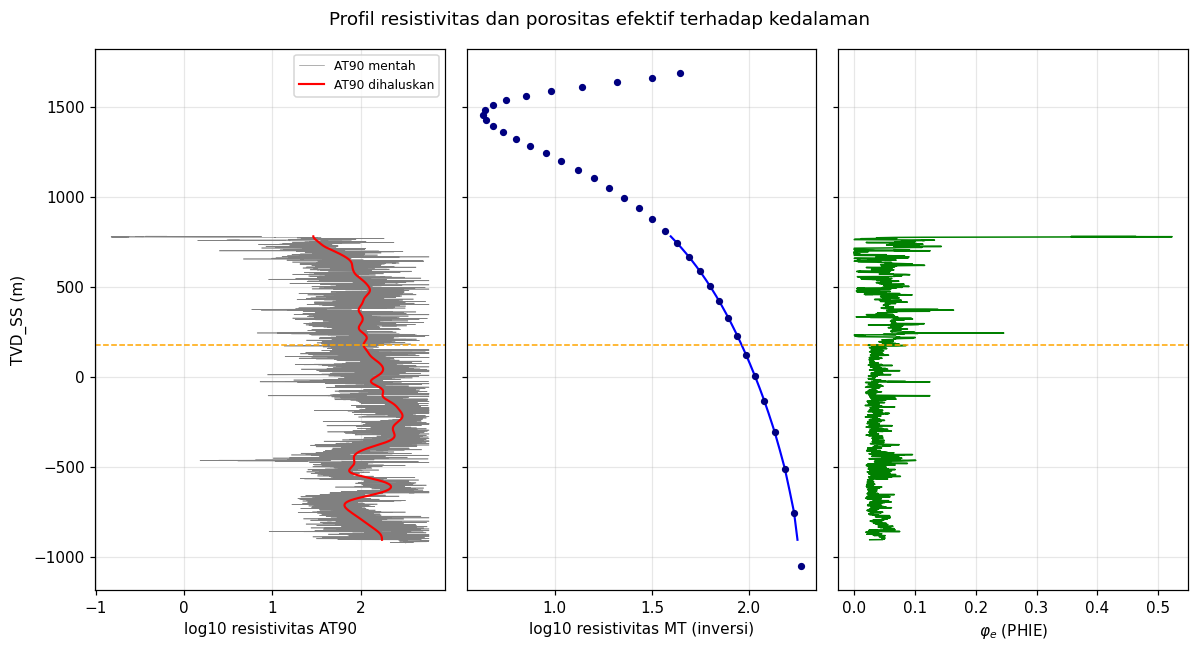

In [16]:
# Profil overlay untuk gambaran umum
fig, ax = plt.subplots(1, 3, figsize=(11, 6), sharey=True)
ax[0].plot(np.log10(at.AT90), at.Z, color='grey', lw=0.4, label='AT90 mentah')
ax[0].plot(log_atsm, grid, color='red', lw=1.4, label='AT90 dihaluskan')
ax[0].set_xlabel('log10 resistivitas AT90'); ax[0].set_ylabel('TVD_SS (m)'); ax[0].legend(fontsize=8)
ax[1].plot(log_mt, grid, color='blue', lw=1.4); ax[1].scatter(np.log10(mt.inv), mt.Z, s=14, color='navy', zorder=3)
ax[1].set_xlabel('log10 resistivitas MT (inversi)')
ax[2].plot(phi_g, grid, color='green', lw=1.0); ax[2].set_xlabel(r'$\varphi_e$ (PHIE)')
for a in ax: a.axhline(ZONE_BOUNDARY_TVDSS, color='orange', ls='--', lw=1)
fig.suptitle('Profil resistivitas dan porositas efektif terhadap kedalaman', y=0.98)
plt.tight_layout(); plt.show()

## 5. Analisis 1: Koefisien Korelasi

Korelasi dihitung antara $\log_{10}(\text{resistivitas})$ dan $\varphi_e$. Pearson mengukur keeratan hubungan linear pada ruang log, sedangkan Spearman mengukur keeratan hubungan monoton secara umum sehingga lebih tahan terhadap ketaklinearan. Nilai negatif diharapkan sesuai hukum Archie, yakni porositas yang lebih tinggi menurunkan resistivitas bulk.

In [17]:
def corr(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    return pearsonr(x[m], y[m])[0], spearmanr(x[m], y[m])[0], int(m.sum())

rows = []
for nama, x, sel in [
    ('AT90 vs PHIE  (keseluruhan)', log_at,   slice(None)),
    ('MT   vs PHIE  (keseluruhan)', log_mt,   slice(None)),
    ('AT90 vs PHIE  (zona dangkal)',log_at,   zoneA),
    ('MT   vs PHIE  (zona dangkal)',log_mt,   zoneA),
    ('AT90 vs PHIE  (zona dalam)',  log_at,   zoneB),
    ('MT   vs PHIE  (zona dalam)',  log_mt,   zoneB),
]:
    idx = np.ones(len(grid), bool) if isinstance(sel, slice) else sel
    pr, sr, n = corr(x[idx], phi_g[idx])
    rows.append([nama, round(pr,3), round(sr,3), n])

tabel = pd.DataFrame(rows, columns=['pasangan','Pearson','Spearman','n'])
display(tabel)

,pasangan,Pearson,Spearman,n
0,AT90 vs PHIE (keseluruhan),-0.454,-0.285,1686
1,MT vs PHIE (keseluruhan),-0.287,-0.273,1686
2,AT90 vs PHIE (zona dangkal),-0.499,-0.213,607
3,MT vs PHIE (zona dangkal),-0.030,0.132,607
4,AT90 vs PHIE (zona dalam),-0.302,-0.205,1079
5,MT vs PHIE (zona dalam),0.113,0.123,1079


## 6. Analisis 2: Plot Sebar Log-Log dan Eksponen Archie Empiris

Hukum Archie menyiratkan $R_o = a\,R_w\,\varphi^{-m}$ sehingga $\log_{10}(R) = c - m\,\log_{10}(\varphi)$. Kemiringan garis regresi pada ruang log-log memberi pendugaan eksponen sementasi empiris $m$, yang kemudian dibandingkan terhadap kisaran lazim batupasir bersih (sekitar 1,3 hingga 2,2). Penyimpangan besar dari kisaran ini mengindikasikan bahwa Archie klasik tidak sepenuhnya berlaku, sebagaimana diharapkan pada reservoir kristalin dengan matriks konduktif.

Eksponen Archie empiris (dari AT90): m = 0.680
Kisaran lazim batupasir bersih     : 1.3 - 2.2


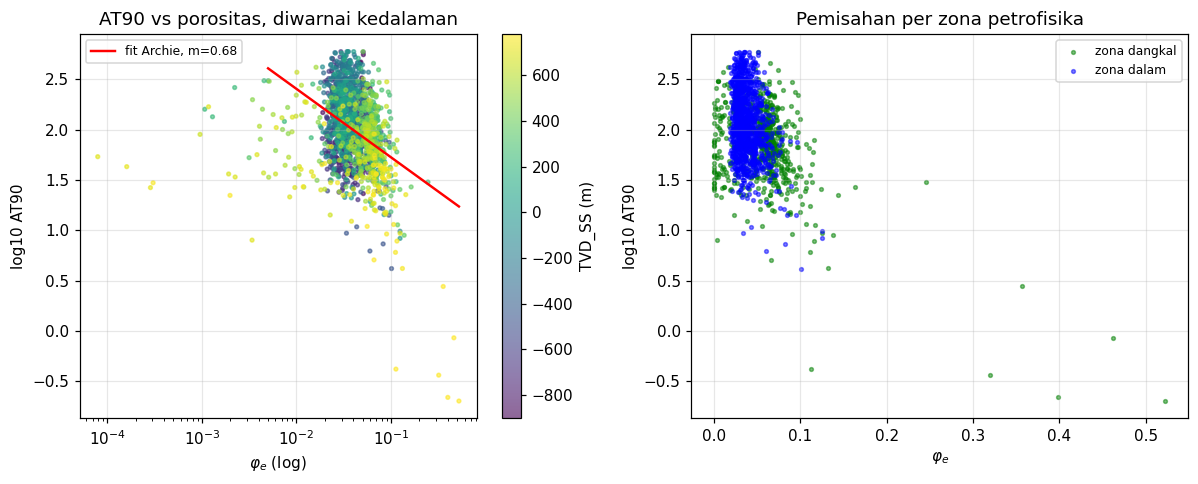

In [18]:
mask = (phi_g > PHI_FLOOR) & np.isfinite(log_at)
slope, intercept = np.polyfit(np.log10(phi_g[mask]), log_at[mask], 1)
m_emp = -slope
print(f"Eksponen Archie empiris (dari AT90): m = {m_emp:.3f}")
print(f"Kisaran lazim batupasir bersih     : 1.3 - 2.2")

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
sc = ax[0].scatter(phi_g, log_at, c=grid, cmap='viridis', s=6, alpha=0.6)
xx = np.linspace(max(PHI_FLOOR, phi_g[mask].min()), phi_g[mask].max(), 100)
ax[0].plot(xx, intercept + slope*np.log10(xx), 'r-', lw=1.6, label=f'fit Archie, m={m_emp:.2f}')
ax[0].set_xscale('log'); ax[0].set_xlabel(r'$\varphi_e$ (log)'); ax[0].set_ylabel('log10 AT90')
ax[0].set_title('AT90 vs porositas, diwarnai kedalaman'); ax[0].legend(fontsize=8)
plt.colorbar(sc, ax=ax[0], label='TVD_SS (m)')

ax[1].scatter(phi_g[zoneA], log_at[zoneA], s=6, alpha=0.5, color='green', label='zona dangkal')
ax[1].scatter(phi_g[zoneB], log_at[zoneB], s=6, alpha=0.5, color='blue',  label='zona dalam')
ax[1].set_xlabel(r'$\varphi_e$'); ax[1].set_ylabel('log10 AT90')
ax[1].set_title('Pemisahan per zona petrofisika'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7. Analisis 3: Perbandingan Archie Baku Header dan Archie-Glover

Header LAS sumur FORGE 78B-32 menyediakan parameter petrofisika yang dipakai operator, yaitu konstanta $a=1$ (FNUM), eksponen sementasi $m=2$ (FEXP), dan resistivitas air formasi $R_w=1{,}0$ Ω·m (RW). Nilai ini memungkinkan perbandingan yang jauh lebih tegas karena konduktivitas fasa fluida tidak lagi difit bebas melainkan dikunci pada $\sigma_f = 1/R_w$.

Archie baku mengasumsikan matriks isolator sehingga $R_o = a\,R_w\,\varphi^{-m} = \varphi^{-2}$. Glover et al. (2000) menambahkan konduktivitas matriks, dan dengan hukum konektivitasnya $(1-\varphi)^p = 1-\varphi^m$ persamaan 2.24 sampai 2.25 pada tesis menyederhana menjadi:

$$\sigma_{eff} = \sigma_f\,\varphi^{m} + \sigma_m\,(1-\varphi^{m})$$

Tiga skema dibandingkan pada pasangan resistivitas dan porositas yang sama. Pertama, Archie baku yang memakai parameter header tanpa pemfitan. Kedua, Archie satu-fasa dengan $m$ dibebaskan untuk melihat nilai yang dipaksakan data. Ketiga, Archie-Glover dengan $\sigma_f$ dikunci pada nilai $R_w$ header sementara $\sigma_m$ dan $m$ difit. Resistivitas matriks $1/\sigma_m$ menjadi diagnostik utama seberapa jauh matriks menyimpang dari isolator ideal.

Perlu dicatat dua hal. $R_w$ header sensitif terhadap suhu, sehingga koreksi ke suhu formasi (BHT sekitar 354 °F pada dasar sumur) akan menurunkan $R_w$ dan menaikkan $\sigma_f$, meski simpulan kualitatif tetap kokoh. Selain itu densitas matriks header bernilai 2,71 g/cc (LIME), sedikit lebih tinggi dari basement granitoid (sekitar 2,65), sehingga porositas densitas berpotensi sedikit terlebih-taksir pada zona kristalin.

In [19]:
from scipy.optimize import curve_fit

a_h, m_h, Rw = FNUM, FEXP, RW_HEADER
sig_f = 1.0 / Rw          # konduktivitas fluida dikunci ke connate water header
sig_g = 1.0 / at_g        # konduktivitas dari AT90 (S/m), skala sumur

# Glover dengan sig_f terkunci: fit sig_m dan m saja
def _gl(phi, sm, m): return np.log10(sig_f*np.power(phi,m) + sm*(1-np.power(phi,m)) + 1e-12)

def analisa_zona(sel, label):
    msk = (phi_g > PHI_FLOOR) & np.isfinite(sig_g) & sel
    x, y = phi_g[msk], np.log10(sig_g[msk])
    # (1) Archie baku header, tanpa fitting
    R_arch = a_h * Rw * np.power(np.clip(phi_g, PHI_FLOOR, None), -m_h)
    rmse_baku = np.sqrt(np.mean((np.log10(R_arch[msk]) - np.log10(at_g[msk]))**2))
    # (2) Archie satu-fasa, m dibebaskan
    m_bebas = -np.polyfit(np.log10(x), np.log10(at_g[msk]), 1)[0]
    # (3) Archie-Glover, sig_f terkunci
    pg,_ = curve_fit(_gl, x, y, p0=[1e-3,2], bounds=([0,0.3],[10,4]), maxfev=60000)
    r2g = 1 - np.sum((y-_gl(x,*pg))**2)/np.sum((y-y.mean())**2)
    return dict(label=label, sel=sel, rmse_baku=rmse_baku, m_bebas=m_bebas,
                m_gl=pg[1], sig_m=pg[0], rho_m=(1/pg[0] if pg[0]>0 else np.inf), r2_gl=r2g, pg=pg)

fits = [analisa_zona(np.ones(len(grid),bool),'Keseluruhan'),
        analisa_zona(zoneA,'Zona dangkal (vulkanik)'),
        analisa_zona(zoneB,'Zona dalam (kristalin EGS)')]

tab_gl = pd.DataFrame([{
    'zona'               : f['label'],
    'RMSE Archie baku'   : round(f['rmse_baku'],3),
    'm bebas (1-fasa)'   : round(f['m_bebas'],2),
    'm Glover'           : round(f['m_gl'],2),
    'rho_matriks (ohm.m)': round(f['rho_m'],0),
    'R2 Glover'          : round(f['r2_gl'],3),
} for f in fits])
display(tab_gl)
print(f"m header (FEXP) = {m_h:.1f}. Perhatikan m Glover memulih mendekati nilai ini "
      f"setelah matriks konduktif diperhitungkan, sedangkan m bebas satu-fasa jatuh ke nilai tak fisis.")

,zona,RMSE Archie baku,m bebas (1-fasa),m Glover,rho_matriks (ohm.m),R2 Glover
0,Keseluruhan,0.906,0.68,1.79,162.0,0.228
1,Zona dangkal (vulkanik),0.914,0.48,1.90,106.0,0.274
2,Zona dalam (kristalin EGS),0.901,0.67,1.77,183.0,0.089


m header (FEXP) = 2.0. Perhatikan m Glover memulih mendekati nilai ini setelah matriks konduktif diperhitungkan, sedangkan m bebas satu-fasa jatuh ke nilai tak fisis.


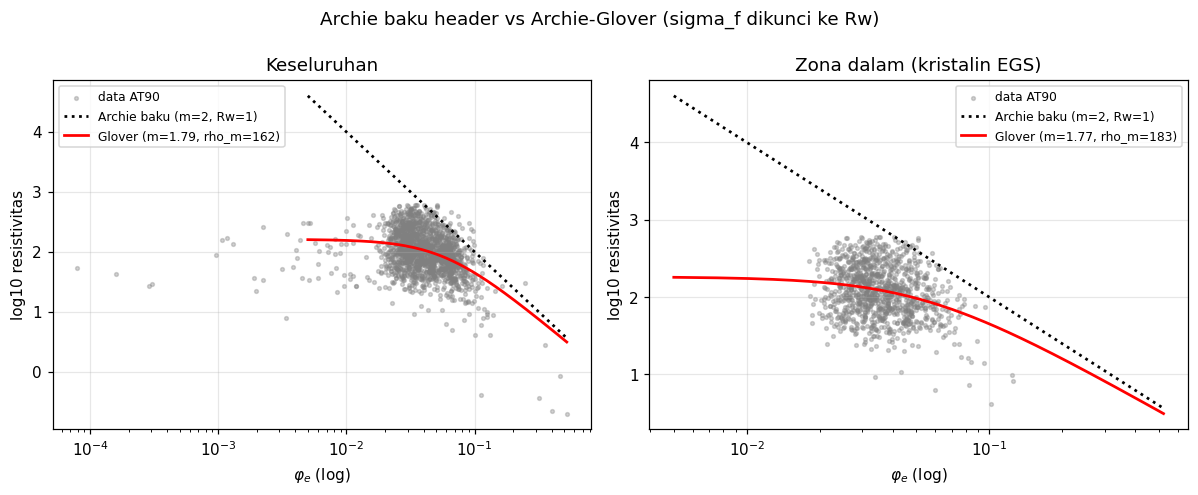

In [20]:
# Overlay pada ruang resistivitas: log10(R) = -log10(sigma_model)
phi_ax = np.linspace(PHI_FLOOR, np.nanmax(phi_g), 200)
panel = [('Keseluruhan', fits[0]), ('Zona dalam (kristalin EGS)', fits[2])]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for a,(judul,f) in zip(ax, panel):
    sel = f['sel']
    a.scatter(phi_g[sel], np.log10(at_g[sel]), s=6, alpha=0.35, color='grey', label='data AT90')
    a.plot(phi_ax, np.log10(a_h*Rw*phi_ax**(-m_h)), 'k:', lw=1.8, label='Archie baku (m=2, Rw=1)')
    a.plot(phi_ax, -_gl(phi_ax, *f['pg']), 'r-', lw=1.8,
           label=f"Glover (m={f['m_gl']:.2f}, rho_m={f['rho_m']:.0f})")
    a.set_xscale('log'); a.set_xlabel(r'$\varphi_e$ (log)'); a.set_ylabel('log10 resistivitas')
    a.set_title(judul); a.legend(fontsize=8)
fig.suptitle('Archie baku header vs Archie-Glover (sigma_f dikunci ke Rw)', y=0.99)
plt.tight_layout(); plt.show()

## 8. Analisis 4: Korelasi Silang Berbasis Lag Kedalaman

Analisis ini menjawab pertanyaan yang berbeda dari korelasi titik ke titik, yakni apakah kedua profil benar-benar sejajar secara kedalaman setelah harmonisasi. Kedua deret di-detrend dan dibakukan (z-score), lalu korelasi silang dihitung sebagai fungsi pergeseran kedalaman. Puncak pada lag mendekati nol menandakan keselarasan yang baik tanpa pergeseran sistematis. Tanda negatif pada puncak menegaskan hubungan yang berlawanan arah, konsisten dengan Archie.

Puncak korelasi silang: lag = -1 m, nilai = -0.426


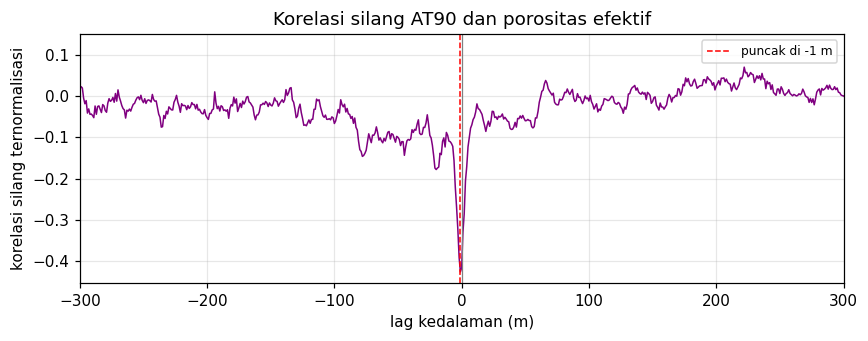

In [21]:
def zdetrend(v):
    v = signal.detrend(v); s = v.std(); return v/s if s>0 else v

a  = zdetrend(log_at)
pp = zdetrend(phi_g)
xc   = signal.correlate(a, pp, mode='full') / len(a)
lags = signal.correlation_lags(len(a), len(pp), mode='full') * GRID_STEP
k = np.argmax(np.abs(xc))
print(f"Puncak korelasi silang: lag = {lags[k]:.0f} m, nilai = {xc[k]:.3f}")

fig, ax = plt.subplots(figsize=(8,3.2))
ax.plot(lags, xc, color='purple', lw=1)
ax.axvline(lags[k], color='red', ls='--', lw=1, label=f'puncak di {lags[k]:.0f} m')
ax.axvline(0, color='grey', lw=0.8)
ax.set_xlim(-300,300); ax.set_xlabel('lag kedalaman (m)'); ax.set_ylabel('korelasi silang ternormalisasi')
ax.set_title('Korelasi silang AT90 dan porositas efektif'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 9. Analisis 5: Efek Resolusi (AT90 versus MT)

Dengan membandingkan kekuatan korelasi AT90 (resolusi tinggi), AT90 dihaluskan (resolusi menengah), dan MT inversi (resolusi kasar) terhadap porositas yang sama, dapat diisolasi seberapa besar pelemahan korelasi bersumber dari hilangnya resolusi akibat inversi dan resampling, bukan dari ketiadaan hubungan fisis.

In [22]:
res_kompar = []
for nama, x in [('AT90 mentah (resolusi tinggi)', log_at),
                ('AT90 dihaluskan (menengah)',   log_atsm),
                ('MT inversi (kasar)',            log_mt)]:
    pr, sr, n = corr(x, phi_g)
    res_kompar.append([nama, round(pr,3), round(sr,3)])
display(pd.DataFrame(res_kompar, columns=['kanal resistivitas','Pearson','Spearman']))

,kanal resistivitas,Pearson,Spearman
0,AT90 mentah (resolusi tinggi),-0.454,-0.285
1,AT90 dihaluskan (menengah),-0.309,-0.288
2,MT inversi (kasar),-0.287,-0.273


## 10. Ringkasan dan Interpretasi

Ganti angka pada narasi berikut jika kamu mengubah parameter. Nilai di bawah dihasilkan dari konfigurasi baku pada file yang diberikan.

**Keterkaitan umum konsisten dengan hukum Archie.** Resistivitas AT90 dan porositas efektif memperlihatkan korelasi negatif taraf sedang (Pearson sekitar -0,45), sesuai dengan prinsip bahwa peningkatan porositas memperbanyak jalur konduktif air formasi sehingga menurunkan resistivitas bulk. Arah korelasi yang konsisten negatif menegaskan bahwa dasar fisis penggunaan resistivitas untuk mengestimasi porositas terpenuhi pada dataset ini.

**Korelasi melemah pada zona dalam kristalin.** Pemisahan per zona menunjukkan keterkaitan yang lebih kuat pada zona dangkal vulkanik-piroklastik dibanding zona dalam. Pada zona dalam yang merepresentasikan reservoar kristalin EGS, korelasi terhadap resistivitas MT mendekati nol bahkan berbalik tanda. Perilaku ini konsisten dengan gugurnya asumsi matriks isolator pada Archie klasik ketika matriks batuan ikut bersifat konduktif akibat mineral lempung alterasi hidrotermal dan porositas rekahan. Pemfitan Archie-Glover pada Bagian 7 mengkuantifikasi hal ini melalui konduktivitas matriks tak nol, sehingga persamaan modified Archie (Glover et al., 2000) lebih relevan sebagai kerangka penjelas pada zona ini.

**Kegagalan Archie bukan pada eksponen, melainkan pada asumsi matriks isolator.** Dengan parameter header operator ($a=1$, $m=2$, $R_w=1{,}0$ Ω·m), Archie baku meleset besar terhadap AT90, dengan RMSE $\log_{10}R$ mendekati 0,9 yang setara kesalahan resistivitas sekitar delapan kali lipat. Bila $m$ dibebaskan pada model satu-fasa, nilainya jatuh ke sekitar 0,7 yang tidak fisis. Namun ketika konduktivitas fluida dikunci pada $\sigma_f=1/R_w$ dan model Archie-Glover diterapkan, eksponen fluida memulih ke kisaran 1,8 sampai 1,9 yang mendekati nilai header $m=2$, disertai resistivitas matriks berhingga sekitar 100 sampai 180 Ω·m. Temuan ini menunjukkan bahwa eksponen sementasi Archie sesungguhnya wajar, dan sumber utama kegagalan adalah pengabaian matriks konduktif hasil alterasi lempung pada reservoar kristalin. Matriks paling konduktif berada pada zona dangkal, konsisten dengan kandungan lempung aluvial dan piroklastik, sedangkan matriks granitoid pada zona dalam lebih resistif namun tetap jauh dari isolator ideal.

**Keselarasan kedalaman terjaga.** Korelasi silang berbasis lag memuncak pada pergeseran mendekati nol dengan nilai negatif, menandakan bahwa proses harmonisasi tidak menimbulkan misalignment kedalaman sistematis antara kanal resistivitas dan porositas, dan hubungan terbalik keduanya terkonfirmasi pada domain spasial.

**Pelemahan korelasi MT sebagian besar bersifat resolusi.** Perbandingan menunjukkan penurunan kekuatan korelasi yang berurutan dari AT90 mentah, AT90 dihaluskan, hingga MT inversi. Pola berjenjang ini mengindikasikan bahwa melemahnya keterkaitan pada kanal MT terutama disebabkan hilangnya resolusi akibat inversi kasar dan resampling, bukan ketiadaan hubungan fisis. Temuan ini memperkuat, bukan melemahkan, narasi keterbatasan resolusi yang telah dibangun pada tahap Quality Control.

**Tindak lanjut yang disarankan.** Selesaikan lebih dulu penetapan zona koreksi Larionov (lihat diagnostik pada Bagian 3) agar batas zona pada analisis korelasi selaras dengan metodologi bab pengolahan data. Setelah itu, pertimbangkan menyajikan tabel korelasi per zona dan plot sebar log-log ini sebagai pelengkap subbab pengolahan data untuk memperkuat justifikasi dataset pelatihan.